<a href="https://colab.research.google.com/github/Shusnigdha/demand-forecasting/blob/main/demand_forecasting_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import pickle

In [2]:
df = pd.read_csv("/content/drive/MyDrive/demand_forecasting_preprocessed.csv")
df.head()

,Unnamed: 0,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,WeekDay,Discounted Price,Sell Through Rate
0,0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632


In [3]:
df = df.drop('Unnamed: 0', axis=1, errors='ignore')
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,WeekDay,Discounted Price,Sell Through Rate
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,...,32.23,Winter,0,64,2024,1,30,Tuesday,28.310,0.270386
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,...,40.73,Winter,0,137,2024,1,30,Tuesday,40.774,0.839416
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,...,19.41,Winter,0,68,2024,1,30,Tuesday,16.029,0.223350
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,...,143.71,Winter,0,84,2024,1,30,Tuesday,151.720,0.464000


In [4]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand', 'Year', 'Month', 'Day', 'WeekDay',
       'Discounted Price', 'Sell Through Rate'],
      dtype='object')

In [5]:
features = ["Epidemic", "Promotion", "Category", "Price", "Weather Condition", "Region", "Discount", "Seasonality", "Competitor Pricing", "Inventory Level", "Month", "WeekDay"]
features

['Epidemic',
 'Promotion',
 'Category',
 'Price',
 'Weather Condition',
 'Region',
 'Discount',
 'Seasonality',
 'Competitor Pricing',
 'Inventory Level',
 'Month',
 'WeekDay']

In [6]:
X = df[features].copy()
X

,Epidemic,Promotion,Category,Price,Weather Condition,Region,Discount,Seasonality,Competitor Pricing,Inventory Level,Month,WeekDay
0,0,0,Electronics,72.72,Snowy,North,5,Winter,85.73,195,1,Saturday
1,0,1,Clothing,80.16,Snowy,North,15,Winter,92.02,117,1,Saturday
2,0,1,Clothing,62.94,Snowy,North,10,Winter,60.08,247,1,Saturday
3,0,0,Electronics,87.63,Snowy,North,10,Winter,85.19,139,1,Saturday
4,0,0,Groceries,54.41,Snowy,North,0,Winter,51.63,152,1,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...
75995,0,0,Toys,29.80,Snowy,North,5,Winter,32.23,233,1,Tuesday
75996,0,0,Toys,42.92,Snowy,North,5,Winter,40.73,137,1,Tuesday
75997,0,0,Clothing,17.81,Snowy,North,10,Winter,19.41,197,1,Tuesday
75998,0,0,Furniture,151.72,Snowy,North,0,Winter,143.71,125,1,Tuesday


In [7]:
Y = df["Demand"]
Y

,Demand
0,115
1,229
2,157
3,52
4,59
...,...
75995,64
75996,137
75997,68
75998,84


In [8]:
label_encoders = {}

categorical_cols = X.select_dtypes(include='object').columns
categorical_cols

Index(['Category', 'Weather Condition', 'Region', 'Seasonality', 'WeekDay'], dtype='object')

In [9]:
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [10]:
label_encoders

{'Category': LabelEncoder(),
 'Weather Condition': LabelEncoder(),
 'Region': LabelEncoder(),
 'Seasonality': LabelEncoder(),
 'WeekDay': LabelEncoder()}

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [12]:
xgb = XGBRegressor(objective = "reg:squarederror", n_jobs = -1)

In [13]:
param_dict = {
     "n_estimators": [200, 300, 500],
     "max_depth": [3, 4, 6, 8],
     "learning_rate": [0.01, 0.05, 0.1],
     "subsample": [0.7, 0.8, 1.0],
     "colsample_bytree": [0.7, 0.8, 1.0],
     "min_child_weight": [1, 3, 5]
}

In [14]:
random_search = RandomizedSearchCV(
    estimator = xgb,
    param_distributions = param_dict,
    scoring = "neg_mean_absolute_error",
    cv = 3,
    verbose= 1,
    n_jobs= -1
)

In [15]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   scoring='neg_mean_absolute_error', verbose=1)

In [16]:
random_search.best_params_

{'subsample': 1.0,
 'n_estimators': 200,
 'min_child_weight': 3,
 'max_depth': 8,
 'learning_rate': 0.1,
 'colsample_bytree': 0.8}

In [17]:
lr = LinearRegression()
rf = RandomForestRegressor(random_state=42)
best_xgb = random_search.best_estimator_

models = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "XGBoost": best_xgb
}

results = []

# Train & evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)
results_df

,Model,MAE,R2 Score
0,Linear Regression,32.260171,0.239320
1,Random Forest,20.722419,0.614631
2,XGBoost,20.474558,0.640321


In [18]:
results_df = results_df.sort_values(by="R2 Score", ascending=False)
results_df

,Model,MAE,R2 Score
2,XGBoost,20.474558,0.640321
1,Random Forest,20.722419,0.614631
0,Linear Regression,32.260171,0.239320


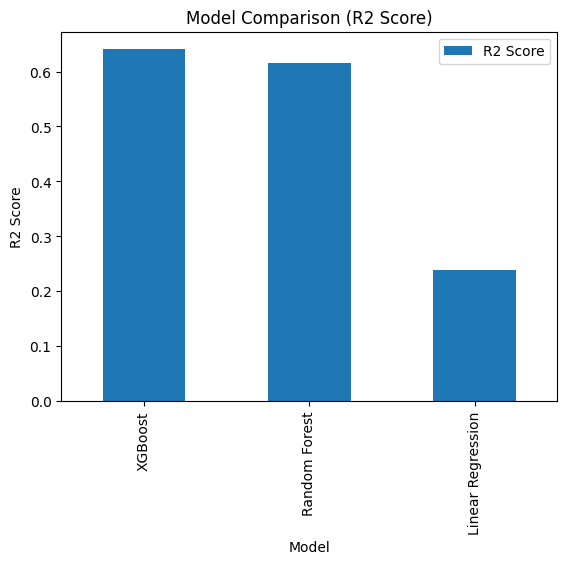

In [19]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[["R2 Score"]].plot(kind="bar")
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.show()

In [20]:
best_model = random_search.best_estimator_

In [21]:
y_pred = best_model.predict(X_test)

In [22]:
best_model.feature_importances_

array([0.37316713, 0.27452734, 0.17975467, 0.03618116, 0.0355922 ,
       0.02546747, 0.01627406, 0.01526083, 0.0143426 , 0.00952611,
       0.01468024, 0.00522626], dtype=float32)

In [23]:
feature_importance = pd.Series(
    best_model.feature_importances_, index=X.columns
).sort_values(ascending=False)
feature_importance

,0
Epidemic,0.373167
Promotion,0.274527
Category,0.179755
Price,0.036181
Weather Condition,0.035592
Region,0.025467
Discount,0.016274
Seasonality,0.015261
Month,0.014680
Competitor Pricing,0.014343


<Axes: title={'center': 'Feature Importance'}>

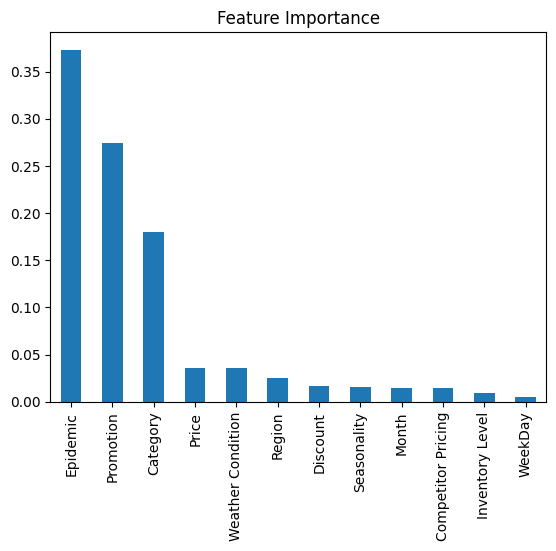

In [24]:
feature_importance.plot(kind='bar', title = "Feature Importance")

### Business Insights

* Epidemic conditions have the highest impact on demand, indicating that external disruptions significantly alter customer purchasing behavior.
* Promotions are a major driver of demand, showing that marketing strategies and offers influence sales more than price changes alone.
* Product category plays a strong role in determining demand, suggesting that different categories exhibit distinct buying patterns.
* Price has relatively low importance compared to promotions, indicating that customers respond more to perceived deals than absolute pricing.
* Weather conditions and region moderately affect demand, highlighting the need for location-specific and environment-aware strategies.
* Discounts alone have limited impact, implying that how offers are presented (promotions) is more effective than just reducing prices.
* Seasonality and monthly trends have a smaller but noticeable influence, acting as supporting factors in demand prediction.
* Competitor pricing has limited impact, suggesting that internal strategies like promotions are more influential than external price competition.
* Inventory levels have minimal effect on demand prediction, indicating they are more relevant for supply management than demand generation.
* Day-of-week variations are negligible, suggesting relatively stable demand across different days.


In [25]:
with open('label_encoders.pkl', 'wb') as file:
    pickle.dump(label_encoders, file)

In [26]:
with open('demand_forecasting_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)